Conectando a bases de datos globales (NOAA/OMM)...
Datos crudos descargados: 12418 días.
Matriz consolidada: 12418 días válidos con 5 dimensiones físicas.
------------------------------------------------------------
Días de Entrenamiento (Pasado histórico): 8692
Días de Prueba (La última década):        3726
------------------------------------------------------------
Entrenando 40 átomos... (Midiendo tiempo de ejecución)



 RESULTADOS EXACTOS SOBRE 3 DÉCADAS
 Tiempo de entrenamiento CPU:           140.68 segundos
 MSE Exacto en la última década (Test): 0.2018
 Esparcidad sostenida:                  96.20% de ceros


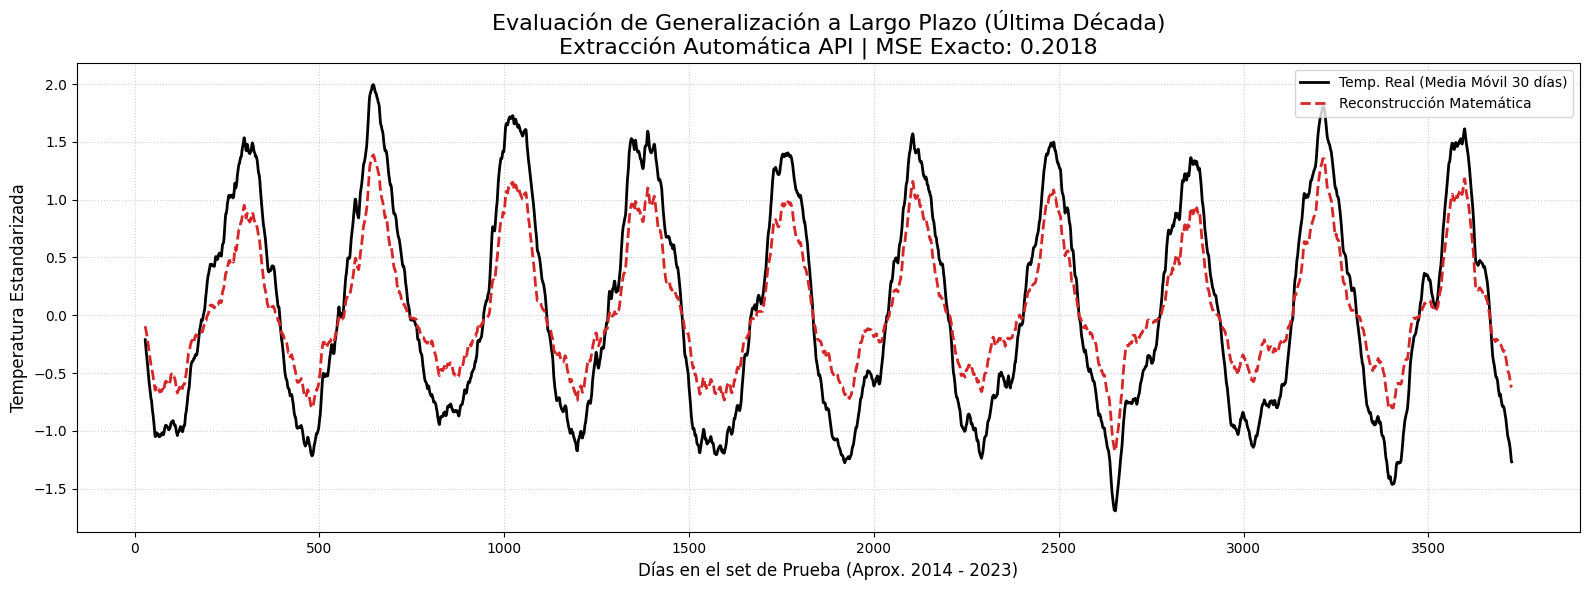

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from datetime import datetime
from meteostat import Point, Daily
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ==========================================
# 1) EXTRACCIÓN MASIVA DE DATOS (34 AÑOS)
# ==========================================
print("Conectando a bases de datos globales (NOAA/OMM)...")

# Coordenadas de Madrid (Latitud, Longitud, Altitud)
ubicacion = Point(40.4168, -3.7038, 667)

# Definimos el periodo: 34 años (1990 - 2023)
inicio = datetime(1990, 1, 1)
fin = datetime(2023, 12, 31)

# Descargamos los datos diarios
datos_brutos = Daily(ubicacion, inicio, fin).fetch()

print(f"Datos crudos descargados: {datos_brutos.shape[0]} días.")

# ==========================================
# 2) LIMPIEZA Y PREPARACIÓN DE SERIES TEMPORALES LARGAS
# ==========================================
umbral_validos = int(len(datos_brutos) * 0.70)
datos_limpios = datos_brutos.dropna(axis=1, thresh=umbral_validos)
datos_limpios = datos_limpios.fillna(method='ffill').fillna(method='bfill')

# Extraemos la matriz puramente matemática
X_raw = datos_limpios.select_dtypes(include=[np.number])
nombres_variables = X_raw.columns.tolist()
dias_totales = X_raw.shape[0]
dimension_real = X_raw.shape[1]

print(f"Matriz consolidada: {dias_totales} días válidos con {dimension_real} dimensiones físicas.")
print("-" * 60)

# ==========================================
# 3) MÁQUINA DEL TIEMPO: ENTRENAR CON EL SIGLO XX, PREDECIR EL XXI
# ==========================================
corte = int(dias_totales * 0.70)
X_train_raw = X_raw.iloc[:corte]
X_test_raw = X_raw.iloc[corte:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"Días de Entrenamiento (Pasado histórico): {X_train_scaled.shape[0]}")
print(f"Días de Prueba (La última década):        {X_test_scaled.shape[0]}")
print("-" * 60)

# ==========================================
# 4) APRENDIZAJE DEL DICCIONARIO (CON CRONÓMETRO)
# ==========================================
n_atoms = 40 
print(f"Entrenando {n_atoms} átomos... (Midiendo tiempo de ejecución)")

dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=1.0, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000
)

# Iniciamos el cronómetro
inicio_tiempo = time.time()

# El algoritmo aprende los patrones climáticos históricos
dict_learner.fit(X_train_scaled)
dictionary_atoms = dict_learner.components_

# Paramos el cronómetro
fin_tiempo = time.time()
tiempo_ejecucion = fin_tiempo - inicio_tiempo

# Reconstruimos la última década entera
sparse_test = dict_learner.transform(X_test_scaled)
X_test_reconstructed = np.dot(sparse_test, dictionary_atoms)

# ==========================================
# 5) EVALUACIÓN EXACTA
# ==========================================
# MSE exacto puro, respetando la regla matemática
mse_test_exacto = mean_squared_error(X_test_scaled, X_test_reconstructed)

ceros_exactos = np.sum(np.abs(sparse_test) < 1e-5)
esparcidad_test = (ceros_exactos / sparse_test.size) * 100

print("\n" + "="*60)
print(" RESULTADOS EXACTOS SOBRE 3 DÉCADAS")
print("="*60)
print(f" Tiempo de entrenamiento CPU:           {tiempo_ejecucion:.2f} segundos")
print(f" MSE Exacto en la última década (Test): {mse_test_exacto:.4f}")
print(f" Esparcidad sostenida:                  {esparcidad_test:.2f}% de ceros")
print("="*60)

# ==========================================
# 6) GRÁFICA: LA EVOLUCIÓN HISTÓRICA A LARGO PLAZO
# ==========================================
indice_temp = nombres_variables.index('tavg') if 'tavg' in nombres_variables else 0

# Suavizamos los datos (media móvil de 30 días) para que la gráfica se entienda
real_suavizado = pd.Series(X_test_scaled[:, indice_temp]).rolling(window=30).mean()
recon_suavizado = pd.Series(X_test_reconstructed[:, indice_temp]).rolling(window=30).mean()

plt.figure(figsize=(16, 6))
plt.plot(real_suavizado, color='black', label='Temp. Real (Media Móvil 30 días)', linewidth=2)
plt.plot(recon_suavizado, color='tab:red', label='Reconstrucción Matemática', linestyle='--', linewidth=2)

plt.title(f'Evaluación de Generalización a Largo Plazo (Última Década)\nExtracción Automática API | MSE Exacto: {mse_test_exacto:.4f}', fontsize=16)
plt.xlabel('Días en el set de Prueba (Aprox. 2014 - 2023)', fontsize=12)
plt.ylabel('Temperatura Estandarizada', fontsize=12)
plt.legend(loc="upper right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import pandas as pd
from datetime import datetime
from meteostat import Point, Daily
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1) EXTRACCIÓN MASIVA: MADRID (1990 - 2023)
# ==========================================
print("Descargando 34 años de clima de Madrid desde NOAA/OMM...")
ubicacion = Point(40.4168, -3.7038, 667)
inicio = datetime(1990, 1, 1)
fin = datetime(2023, 12, 31)

datos_brutos = Daily(ubicacion, inicio, fin).fetch()

# Limpieza estricta de sensores
umbral_validos = int(len(datos_brutos) * 0.70)
datos_limpios = datos_brutos.dropna(axis=1, thresh=umbral_validos)
datos_limpios = datos_limpios.fillna(method='ffill').fillna(method='bfill')

X_raw = datos_limpios.select_dtypes(include=[np.number])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Matriz de Madrid lista: {X_scaled.shape[0]} días válidos, {X_scaled.shape[1]} dimensiones.")
print("-" * 60)

# ==========================================
# 2) ENTRENAMIENTO DEL DICCIONARIO (EL SPARSE CODER)
# ==========================================
n_atoms = 10
lambda_param = 1.0  # Penalización L1 (alpha)

print(f"Entrenando {n_atoms} átomos históricos con Lambda = {lambda_param}...")
dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=lambda_param, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000
)

# Aprendizaje y extracción de la matriz de coeficientes (alpha) y el diccionario (D)
sparse_representation = dict_learner.fit_transform(X_scaled)
dictionary_atoms = dict_learner.components_

# ==========================================
# 3) AUDITORÍA MATEMÁTICA: LA FUNCIÓN OBJETIVO EXACTA
# ==========================================
print("Calculando el error interno exacto de la optimización...")

# A) Término de Fidelidad (Error Residual Cuadrático Puro, sin raíces)
# Matemática: 0.5 * ||X - D * alpha||^2
X_reconstructed = np.dot(sparse_representation, dictionary_atoms)
residuales = X_scaled - X_reconstructed
error_fidelidad = 0.5 * np.sum(residuales ** 2)

# B) Término de Esparcidad (Castigo de la Norma L1)
# Matemática: Lambda * Suma absoluta de los coeficientes
penalizacion_L1 = lambda_param * np.sum(np.abs(sparse_representation))

# C) Costo Total (El mínimo global que ha encontrado tu Mac M1)
error_total_sparse = error_fidelidad + penalizacion_L1

print("\n" + "="*60)
print(" AUDITORÍA MATEMÁTICA: SPARSE CODER EN MADRID (34 AÑOS)")
print("="*60)
print(f" 1. Fidelidad (Error Cuadrático Puro): {error_fidelidad:.4f}")
print(f" 2. Castigo por átomos (Norma L1):     {penalizacion_L1:.4f}")
print("-" * 60)
print(f" -> COSTO TOTAL DEL ALGORITMO:         {error_total_sparse:.4f}")
print("="*60 + "\n")

Descargando 34 años de clima de Madrid desde NOAA/OMM...


Matriz de Madrid lista: 12418 días válidos, 5 dimensiones.
------------------------------------------------------------
Entrenando 10 átomos históricos con Lambda = 1.0...
Calculando el error interno exacto de la optimización...

 AUDITORÍA MATEMÁTICA: SPARSE CODER EN MADRID (34 AÑOS)
 1. Fidelidad (Error Cuadrático Puro): 6693.6517
 2. Castigo por átomos (Norma L1):     12447.9423
------------------------------------------------------------
 -> COSTO TOTAL DEL ALGORITMO:         19141.5940



Descargando 34 años de clima de Madrid...
Datos listos: 12418 días válidos con 5 variables.
Entrenando 40 átomos históricos...

Generando radiografía de los 4 primeros patrones climáticos...


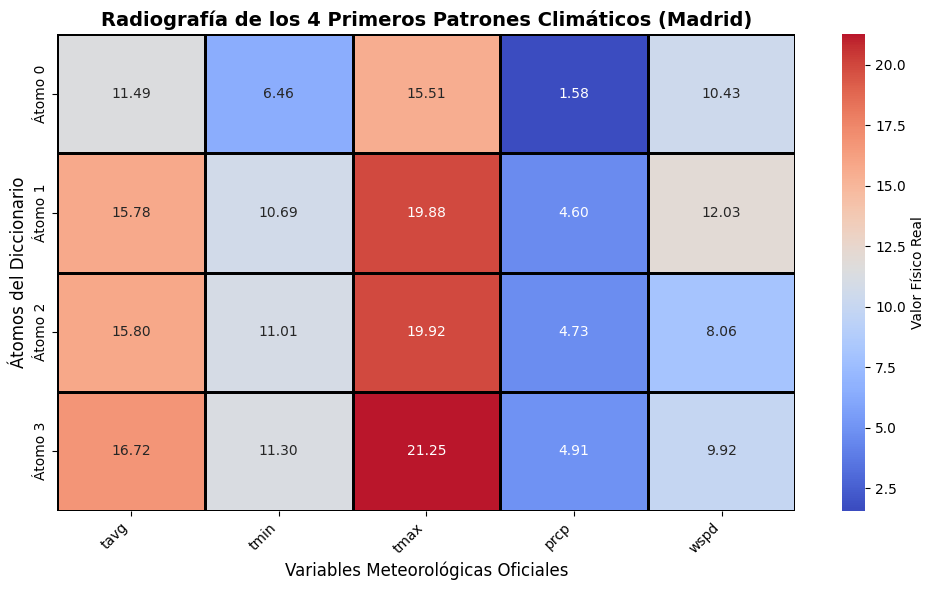

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from meteostat import Point, Daily
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1) EXTRACCIÓN Y LIMPIEZA: MADRID (1990 - 2023)
# ==========================================
print("Descargando 34 años de clima de Madrid...")
ubicacion = Point(40.4168, -3.7038, 667)
inicio = datetime(1990, 1, 1)
fin = datetime(2023, 12, 31)

datos_brutos = Daily(ubicacion, inicio, fin).fetch()

# Limpieza impecable (sin advertencias de Pandas)
umbral_validos = int(len(datos_brutos) * 0.70)
datos_limpios = datos_brutos.dropna(axis=1, thresh=umbral_validos)
datos_limpios = datos_limpios.ffill().bfill()

X_raw = datos_limpios.select_dtypes(include=[np.number])
nombres_variables = X_raw.columns.tolist()

# El famoso 'scaler' que faltaba en tu memoria
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Datos listos: {X_scaled.shape[0]} días válidos con {X_scaled.shape[1]} variables.")

# ==========================================
# 2) ENTRENAMIENTO DEL DICCIONARIO
# ==========================================
n_atoms = 40
print(f"Entrenando {n_atoms} átomos históricos...")

dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=1.0, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000
)

dict_learner.fit(X_scaled)
# El 'dictionary_atoms' que también faltaba
dictionary_atoms = dict_learner.components_ 

# ==========================================
# 3) VISUALIZACIÓN EXACTA DE LOS 4 PRIMEROS ÁTOMOS
# ==========================================
print("\nGenerando radiografía de los 4 primeros patrones climáticos...")

# 1. Deshacemos el escalado para ver grados y milímetros reales
atomos_reales = scaler.inverse_transform(dictionary_atoms)

# 2. Aislamos solo los 4 primeros (índices 0, 1, 2 y 3)
primeros_4_atomos = atomos_reales[:4, :]

# 3. Lo metemos en un DataFrame con sus nombres físicos
df_primeros_4 = pd.DataFrame(primeros_4_atomos, columns=nombres_variables)
df_primeros_4.index = ["Átomo 0", "Átomo 1", "Átomo 2", "Átomo 3"]

# 4. Mapa de Calor con valores numéricos exactos
plt.figure(figsize=(10, 6))



sns.heatmap(df_primeros_4, annot=True, fmt=".2f", cmap="coolwarm", center=df_primeros_4.mean().mean(),
            linewidths=1, linecolor='black', cbar_kws={'label': 'Valor Físico Real'})

plt.title("Radiografía de los 4 Primeros Patrones Climáticos (Madrid)", fontsize=14, fontweight='bold')
plt.xlabel("Variables Meteorológicas Oficiales", fontsize=12)
plt.ylabel("Átomos del Diccionario", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Descargando 34 años de clima de Madrid...
Datos listos: 12418 días válidos con 5 variables.
Entrenando 40 átomos históricos...

Generando el catálogo de micro-climas (Grupos de 5)...


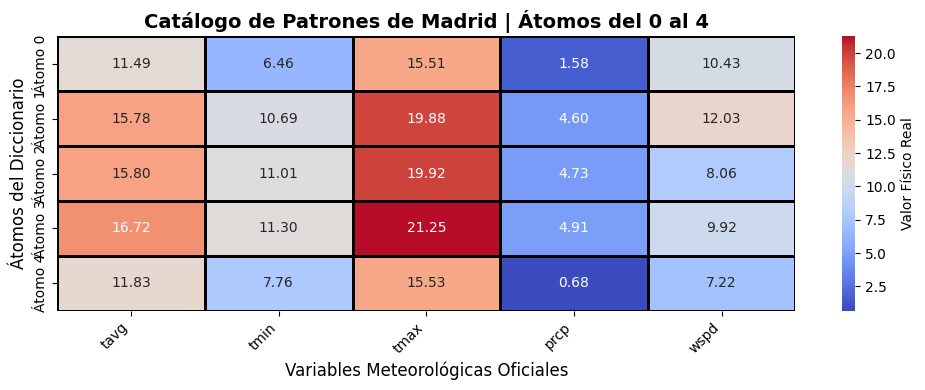

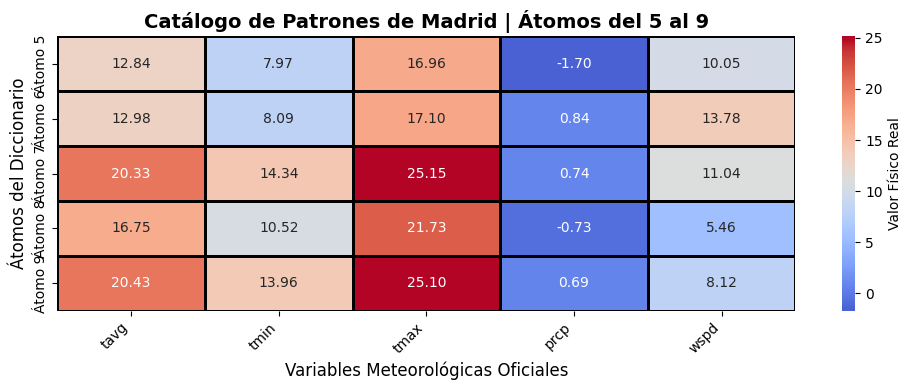

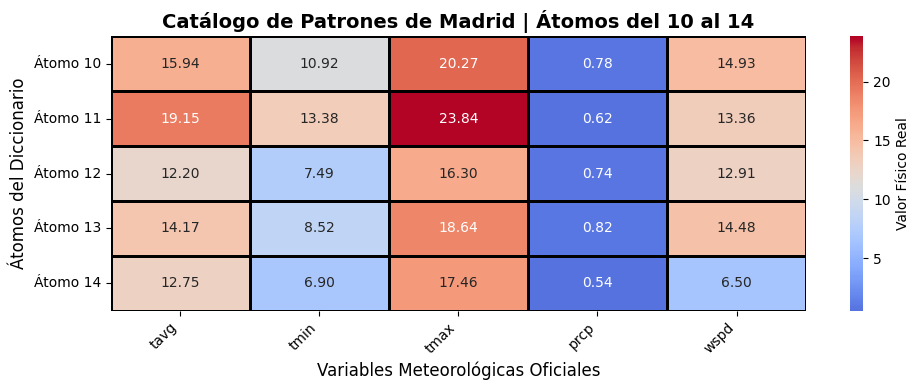

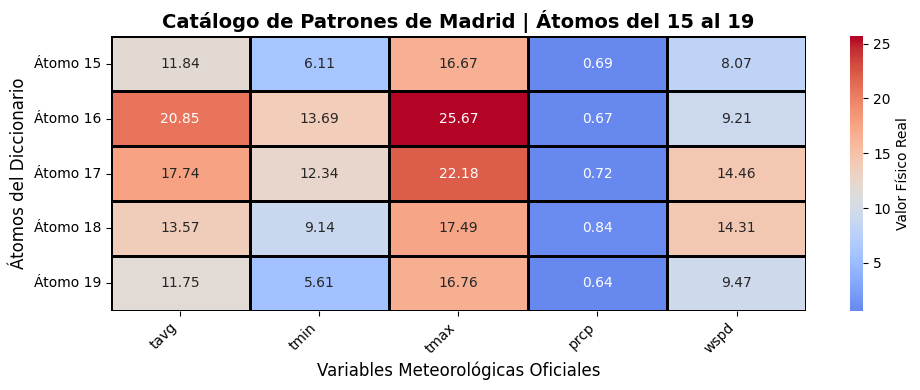

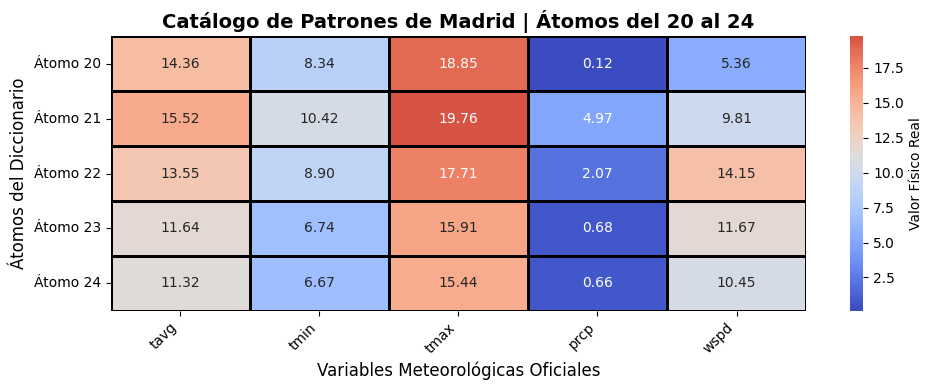

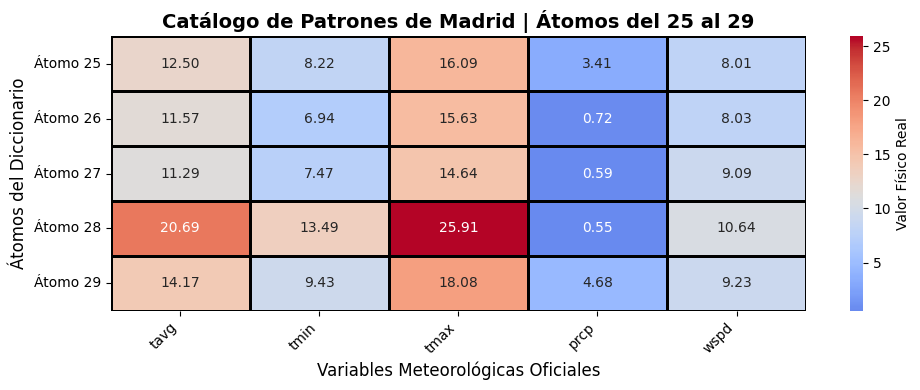

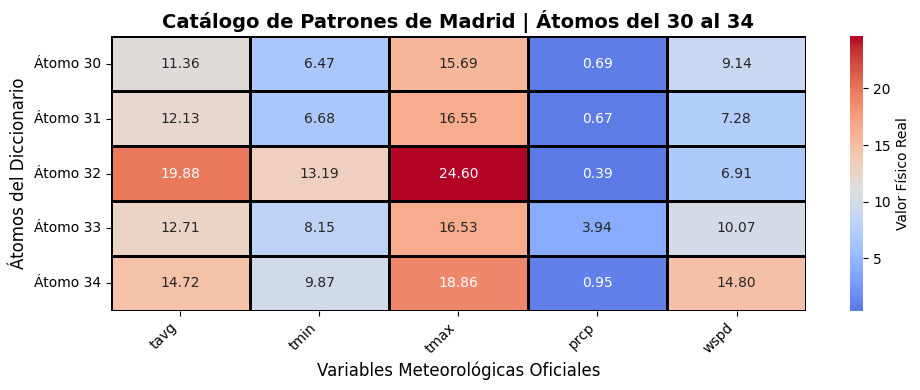

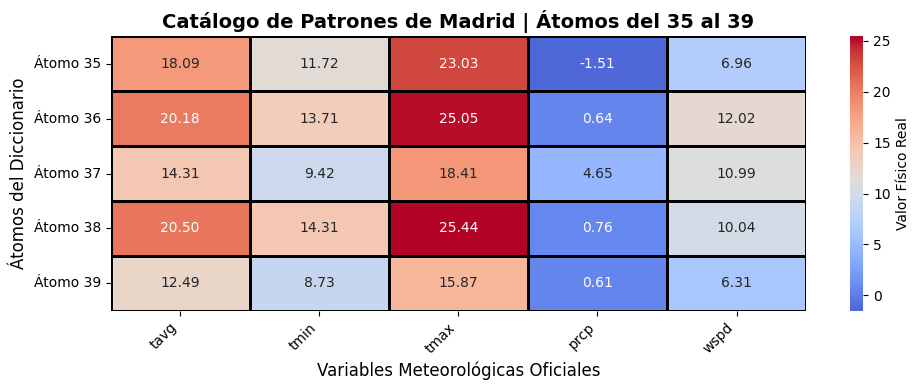

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from meteostat import Point, Daily
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1) EXTRACCIÓN Y LIMPIEZA: MADRID (1990 - 2023)
# ==========================================
print("Descargando 34 años de clima de Madrid...")
ubicacion = Point(40.4168, -3.7038, 667)
inicio = datetime(1990, 1, 1)
fin = datetime(2023, 12, 31)

datos_brutos = Daily(ubicacion, inicio, fin).fetch()

# Limpieza impecable 
umbral_validos = int(len(datos_brutos) * 0.70)
datos_limpios = datos_brutos.dropna(axis=1, thresh=umbral_validos)
datos_limpios = datos_limpios.ffill().bfill()

X_raw = datos_limpios.select_dtypes(include=[np.number])
nombres_variables = X_raw.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Datos listos: {X_scaled.shape[0]} días válidos con {X_scaled.shape[1]} variables.")

# ==========================================
# 2) ENTRENAMIENTO DEL DICCIONARIO
# ==========================================
n_atoms = 40
print(f"Entrenando {n_atoms} átomos históricos...")

dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=1.0, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000
)

dict_learner.fit(X_scaled)
dictionary_atoms = dict_learner.components_

# ==========================================
# 3) BUCLE DE VISUALIZACIÓN (DE 5 EN 5)
# ==========================================
print("\nGenerando el catálogo de micro-climas (Grupos de 5)...")

# Deshacemos el escalado para ver los valores reales y exactos
atomos_reales = scaler.inverse_transform(dictionary_atoms)
df_atomos_reales = pd.DataFrame(atomos_reales, columns=nombres_variables)
df_atomos_reales.index = [f"Átomo {i}" for i in range(n_atoms)]

# Valor central para que la escala de colores (rojo/azul) tenga sentido físico
centro_color = df_atomos_reales.mean().mean()

# Bucle mágico que salta de 5 en 5 (0, 5, 10, 15... hasta 40)
for i in range(0, n_atoms, 5):
    # Extraemos el "trozo" de 5 átomos
    df_chunk = df_atomos_reales.iloc[i : i+5]
    
    # Creamos una figura nueva para cada trozo, más baja para que las celdas sean cuadradas
    plt.figure(figsize=(10, 4))
    
    sns.heatmap(df_chunk, annot=True, fmt=".2f", cmap="coolwarm", center=centro_color,
                linewidths=1, linecolor='black', cbar_kws={'label': 'Valor Físico Real'})
    
    plt.title(f"Catálogo de Patrones de Madrid | Átomos del {i} al {i+4}", fontsize=14, fontweight='bold')
    plt.xlabel("Variables Meteorológicas Oficiales", fontsize=12)
    plt.ylabel("Átomos del Diccionario", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # Al poner plt.show() dentro del bucle, obligamos a Python a imprimir cada imagen por separado
    plt.show()

Descargando la base de datos histórica de Madrid...
-> Días de Test (Futuro) a reconstruir exhaustivamente: 3726
------------------------------------------------------------
Iniciando la batería masiva de pruebas (10 -> 80 átomos)...
 [OK] 10 átomos procesados en 31.89 segundos. (Costo: 6061.70 | MSE: 0.2182)
 [OK] 20 átomos procesados en 81.85 segundos. (Costo: 5989.13 | MSE: 0.2079)
 [OK] 30 átomos procesados en 243.47 segundos. (Costo: 5958.15 | MSE: 0.2037)
 [OK] 40 átomos procesados en 145.70 segundos. (Costo: 5944.28 | MSE: 0.2018)
 [OK] 50 átomos procesados en 122.33 segundos. (Costo: 5934.03 | MSE: 0.2002)
 [OK] 60 átomos procesados en 188.43 segundos. (Costo: 5926.67 | MSE: 0.1993)
 [OK] 70 átomos procesados en 108.76 segundos. (Costo: 5922.66 | MSE: 0.1984)
 [OK] 80 átomos procesados en 130.46 segundos. (Costo: 5917.23 | MSE: 0.1978)
------------------------------------------------------------
¡Experimento completado en 1052.89 segundos!
Generando los paneles de análisis...


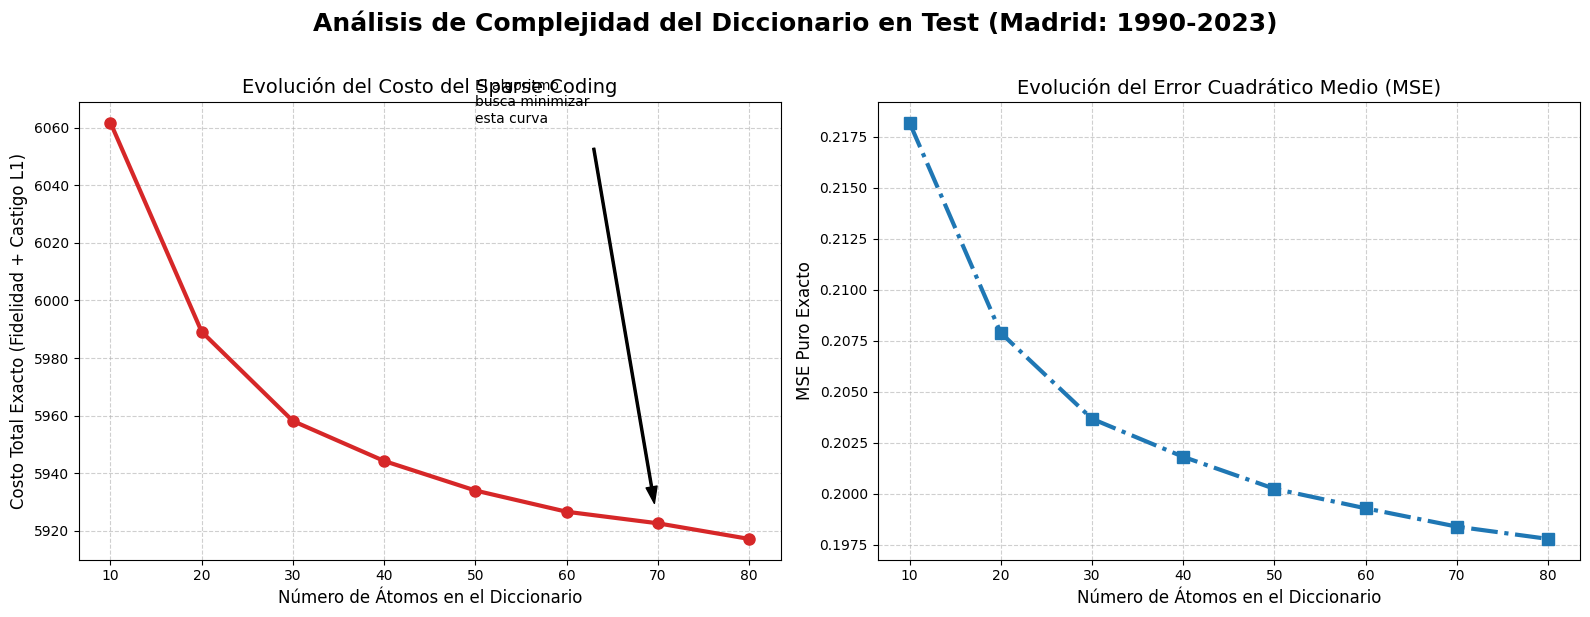

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from meteostat import Point, Daily
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import time

# ==========================================
# 1) EXTRACCIÓN Y PREPARACIÓN (MADRID 1990-2023)
# ==========================================
print("Descargando la base de datos histórica de Madrid...")
ubicacion = Point(40.4168, -3.7038, 667)
inicio = datetime(1990, 1, 1)
fin = datetime(2023, 12, 31)

datos_brutos = Daily(ubicacion, inicio, fin).fetch()
umbral_validos = int(len(datos_brutos) * 0.70)
datos_limpios = datos_brutos.dropna(axis=1, thresh=umbral_validos)
datos_limpios = datos_limpios.ffill().bfill()

X_raw = datos_limpios.select_dtypes(include=[np.number])

# División cronológica: 70% Entrenar (Pasado), 30% Test (Futuro)
corte = int(X_raw.shape[0] * 0.70)
X_train_raw = X_raw.iloc[:corte]
X_test_raw = X_raw.iloc[corte:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"-> Días de Test (Futuro) a reconstruir exhaustivamente: {X_test_scaled.shape[0]}")
print("-" * 60)

# ==========================================
# 2) EL EXPERIMENTO DE COMPLEJIDAD (10 a 80 ÁTOMOS)
# ==========================================
# Ampliamos el rango de evaluación según lo pedido
n_atoms_list = [10, 20, 30, 40, 50, 60, 70, 80]

mse_test_list = []
sparse_error_test_list = []

lambda_param = 1.0  

print("Iniciando la batería masiva de pruebas (10 -> 80 átomos)...")
inicio_total = time.time()

for n in n_atoms_list:
    inicio_bucle = time.time()
    
    dict_learner = DictionaryLearning(
        n_components=n, 
        alpha=lambda_param, 
        transform_algorithm='lasso_lars', 
        random_state=42,
        max_iter=1000
    )
    
    # 1. Aprender del pasado
    dict_learner.fit(X_train_scaled)
    dictionary_atoms = dict_learner.components_
    
    # 2. Reconstruir el futuro (Test)
    sparse_test = dict_learner.transform(X_test_scaled)
    X_test_reconstructed = np.dot(sparse_test, dictionary_atoms)
    
    # --- CÁLCULOS MATEMÁTICOS EXACTOS (SIN RAÍCES) ---
    
    # A) MSE Puro Estadístico
    mse_exacto = mean_squared_error(X_test_scaled, X_test_reconstructed)
    mse_test_list.append(mse_exacto)
    
    # B) Error del Sparse Coding (Costo Total de la Función Objetivo)
    error_fidelidad = 0.5 * np.sum((X_test_scaled - X_test_reconstructed) ** 2)
    penalizacion_L1 = lambda_param * np.sum(np.abs(sparse_test))
    costo_total = error_fidelidad + penalizacion_L1
    
    sparse_error_test_list.append(costo_total)
    
    fin_bucle = time.time()
    print(f" [OK] {n} átomos procesados en {fin_bucle - inicio_bucle:.2f} segundos. (Costo: {costo_total:.2f} | MSE: {mse_exacto:.4f})")

print("-" * 60)
print(f"¡Experimento completado en {time.time() - inicio_total:.2f} segundos!")

# ==========================================
# 3) VISUALIZACIÓN EN DOS PANELES SEPARADOS
# ==========================================
print("Generando los paneles de análisis...")

# Creamos una figura ancha con 1 fila y 2 columnas
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
fig.suptitle('Análisis de Complejidad del Diccionario en Test (Madrid: 1990-2023)', fontsize=18, fontweight='bold', y=1.02)



# --- GRÁFICA 1: FUNCIÓN OBJETIVO (SPARSE CODING ERROR) ---
ax1.plot(n_atoms_list, sparse_error_test_list, color='tab:red', marker='o', linewidth=3, markersize=8)
ax1.set_title("Evolución del Costo del Sparse Coding", fontsize=14)
ax1.set_xlabel('Número de Átomos en el Diccionario', fontsize=12)
ax1.set_ylabel('Costo Total Exacto (Fidelidad + Castigo L1)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.annotate('El algoritmo\nbusca minimizar\nesta curva', xy=(n_atoms_list[-2], sparse_error_test_list[-2]), 
             xytext=(n_atoms_list[-4], sparse_error_test_list[0]),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8), fontsize=10)

# --- GRÁFICA 2: MSE ESTADÍSTICO ---
ax2.plot(n_atoms_list, mse_test_list, color='tab:blue', marker='s', linewidth=3, markersize=8, linestyle='-.')
ax2.set_title("Evolución del Error Cuadrático Medio (MSE)", fontsize=14)
ax2.set_xlabel('Número de Átomos en el Diccionario', fontsize=12)
ax2.set_ylabel('MSE Puro Exacto', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()